In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

In [26]:
torch.manual_seed(42)

In [27]:
df=pd.read_csv('fmnist_small.csv')
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


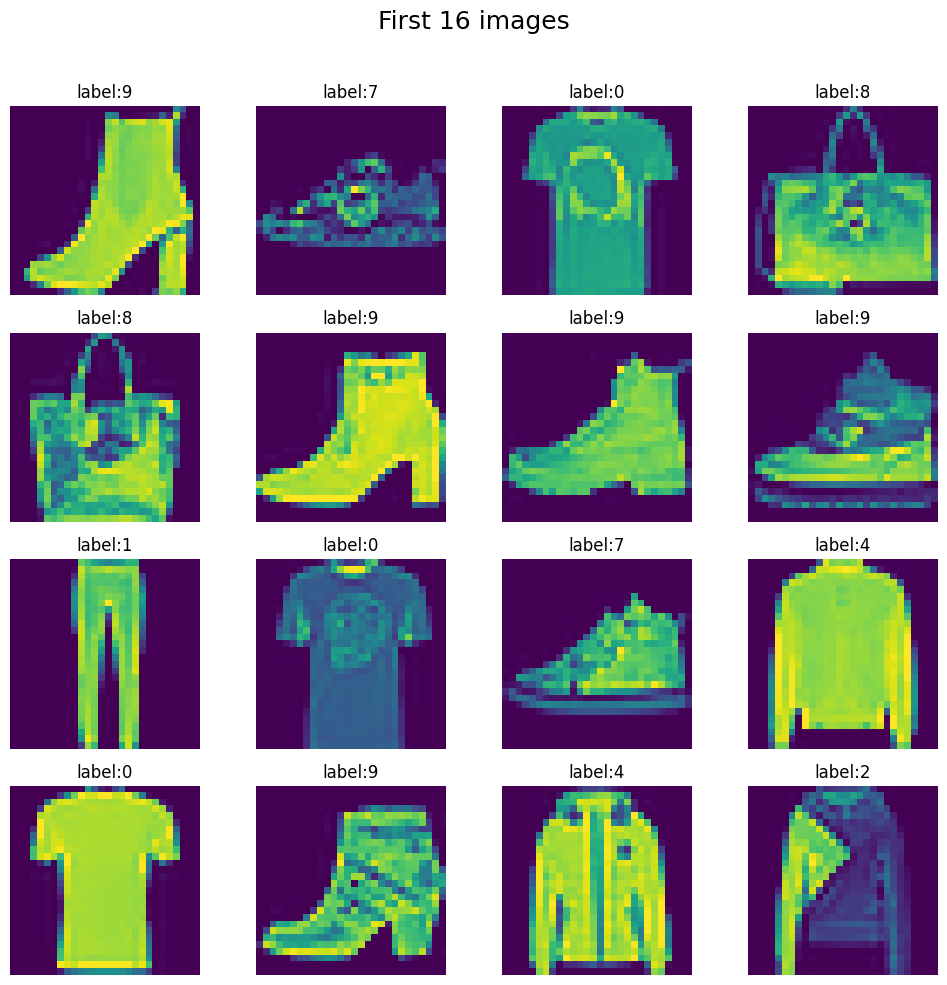

In [28]:
#create 4x4 grid images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=18)
#now plot the 16 images from the dataset
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)  #display in grayscale
    ax.axis('off') #this is just removing the axes
    ax.set_title(f"label:{df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])  #adjust layout to fit the title
plt.show()


In [29]:
#train_test_split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [40]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
#scaling the features
X_train=X_train/255.0
X_test=X_test/255.0

In [42]:
#create CustomDataset class
class CustomDataset(Dataset):
  def __init__(self,X,y):
    self.features=torch.tensor(X,dtype=torch.float32)
    self.labels=torch.tensor(y,dtype=torch.long)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [43]:
#create train_dataset obj
train_dataset=CustomDataset(X_train,y_train)

In [44]:
#create test_dataset obj
test_dataset=CustomDataset(X_test,y_test)

In [45]:
#create train and test loder
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False) #we dont want to shuffle when predicting

In [46]:
#DEFINE NN class
class My_NN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)    #we are not doing softmax here, since pytorch has defined softmax internally in cross-entropy loss
    )

  def forward(self,x):
    return self.model(x)

In [50]:
#set learning rate and epochs
learning_rate=0.35
epochs=110

In [51]:
#instantiate the model
model=My_NN(X_train.shape[1])
loss_fun=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [52]:
#training loop
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:
    #forward pass
    out=model(batch_features)

    #calcualte loss
    loss=loss_fun(out,batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()
    #optimizer-update the grads
    optimizer.step()
    total_epoch_loss=total_epoch_loss+loss.item()
  print(f"Avg loss in epoch{epoch+1}:{total_epoch_loss/len(train_dataset)}")

Avg loss in epoch1:0.03804493195066849
Avg loss in epoch2:0.02419657898445924
Avg loss in epoch3:0.02112528420363863
Avg loss in epoch4:0.01927179944391052
Avg loss in epoch5:0.017219009455293418
Avg loss in epoch6:0.015886856764554976
Avg loss in epoch7:0.015749036950680115
Avg loss in epoch8:0.01455783200605462
Avg loss in epoch9:0.013261337960138918
Avg loss in epoch10:0.013138114695126811
Avg loss in epoch11:0.012607570933178068
Avg loss in epoch12:0.011724580461159349
Avg loss in epoch13:0.011180215297887723
Avg loss in epoch14:0.011002093035106858
Avg loss in epoch15:0.010055109243839979
Avg loss in epoch16:0.010837715230882167
Avg loss in epoch17:0.010303191028845807
Avg loss in epoch18:0.009361148606985807
Avg loss in epoch19:0.009755075724485019
Avg loss in epoch20:0.009147140625864268
Avg loss in epoch21:0.009272682465768109
Avg loss in epoch22:0.008310045547938596
Avg loss in epoch23:0.008150984555638084
Avg loss in epoch24:0.007522355890832841
Avg loss in epoch25:0.00833526

In [53]:
#set model to eval
model.eval()

My_NN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [54]:
#eval code
total=0
correct=0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    out=model(batch_features)
    _,predicted=torch.max(out,1)
    total=total+batch_labels.shape[0]
    correct=correct+(predicted==batch_labels).sum().item()
print(f"Accuracy:{correct/total}")


Accuracy:0.8275
